# Bike sharing pediction
**Dani tri p** | **8/25/2026** | **Tools:** Python, Pandas, Scikit-learn

## Latar Belakang & Tujuan Bisnis
Perusahaan penyewaan sepeda ingin mengoptimalkan ketersediaan sepeda di berbagai jam. 
Tujuan dari proyek ini adalah untuk **memprediksi jumlah total sepeda yang disewa (cnt)** 
berdasarkan fitur waktu, cuaca, dan kondisi hari. Model ini diharapkan dapat membantu 
perusahaan menghindari kehabisan stok di jam sibuk atau kelebihan stok di jam sepi.

In [3]:
import pandas as pd 
import numpy as np

In [4]:
df = pd.read_csv('hour.csv')
df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.4 MB


In [6]:
display(df.describe())

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [7]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df['dteday'] = pd.to_datetime(df['dteday'])
df['day_name'] = df['dteday'].dt.day_name()

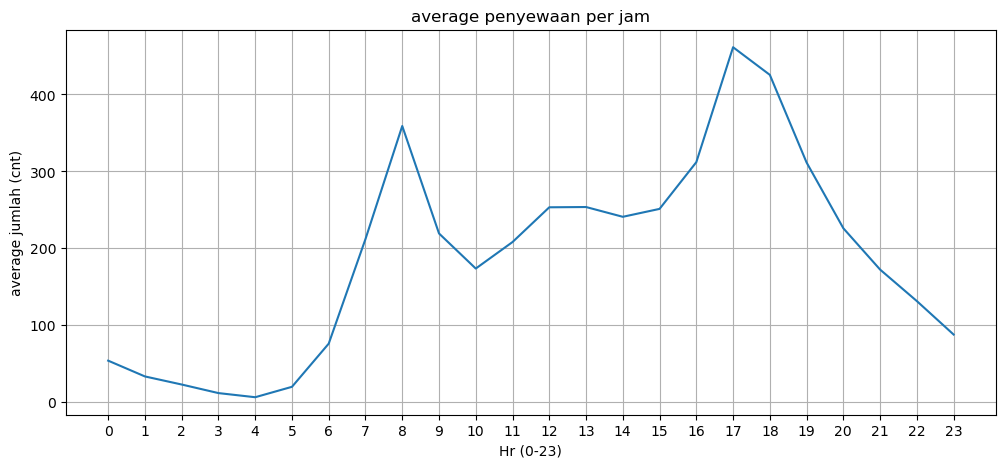

In [10]:
plt.figure(figsize=(12, 5))
sns.lineplot(x='hr', y='cnt', data=df,  estimator='mean', errorbar=None)
plt.title('average penyewaan per jam')
plt.xlabel('Hr (0-23)')
plt.ylabel('average jumlah (cnt)')
plt.xticks(range (0, 24))
plt.grid(True)
plt.show()

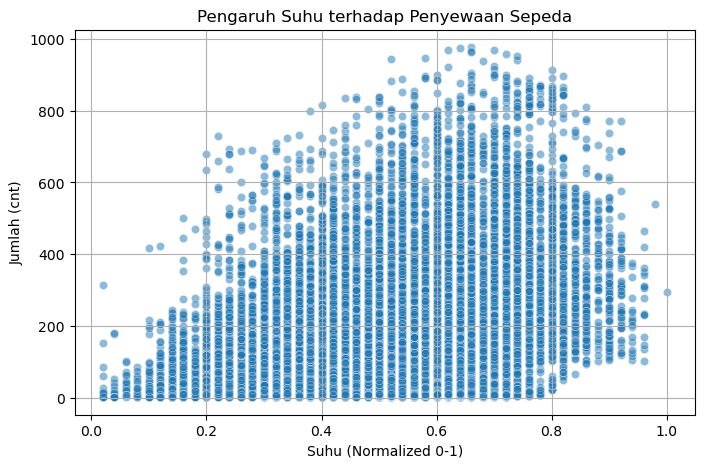

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='temp', y='cnt', data=df, alpha=0.5)
plt.title('Pengaruh Suhu terhadap Penyewaan Sepeda')
plt.xlabel('Suhu (Normalized 0-1)')
plt.ylabel('Jumlah (cnt)')
plt.grid(True)
plt.show()

In [12]:
features = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']
X = df[features]
y = df['cnt']

In [13]:
X = pd.get_dummies(X, columns=['season', 'weathersit', 'mnth', 'weekday'], drop_first=True)
print('bentuk data adfter encode:', X.shape)
display(X.head())

bentuk data adfter encode: (17379, 31)


,yr,hr,holiday,workingday,temp,atemp,hum,windspeed,season_2,season_3,...,mnth_9,mnth_10,mnth_11,mnth_12,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
0,0,0,0,0,0.24,0.2879,0.81,0.0,False,False,...,False,False,False,False,False,False,False,False,False,True
1,0,1,0,0,0.22,0.2727,0.80,0.0,False,False,...,False,False,False,False,False,False,False,False,False,True
2,0,2,0,0,0.22,0.2727,0.80,0.0,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0,3,0,0,0.24,0.2879,0.75,0.0,False,False,...,False,False,False,False,False,False,False,False,False,True
4,0,4,0,0,0.24,0.2879,0.75,0.0,False,False,...,False,False,False,False,False,False,False,False,False,True


In [14]:
df.shape

(17379, 18)

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'{X_train.shape}')
print(f'{X_test.shape}')


(13903, 31)
(3476, 31)


In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
y_pred = model.predict(X_test)

HASIL EVALUASI MODEL
Mean Absolute Error (MAE): 103.14
Root Mean Squared Error (RMSE): 136.85
R-Squared (R2): 0.4086


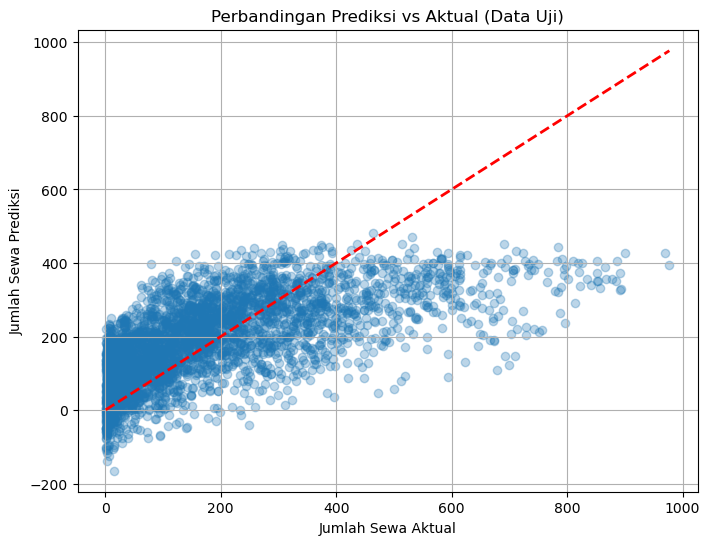

In [19]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("HASIL EVALUASI MODEL")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-Squared (R2): {r2:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Garis merah ideal
plt.xlabel('Jumlah Sewa Aktual')
plt.ylabel('Jumlah Sewa Prediksi')
plt.title('Perbandingan Prediksi vs Aktual (Data Uji)')
plt.grid(True)
plt.show()

In [20]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators = 100, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
y_pred_rf = rf_model.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("HASIL EVALUASI RANDOM FOREST")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R-Squared (R2): {r2_rf:.4f}")

HASIL EVALUASI RANDOM FOREST
Mean Absolute Error (MAE): 25.48
Root Mean Squared Error (RMSE): 42.87
R-Squared (R2): 0.9420


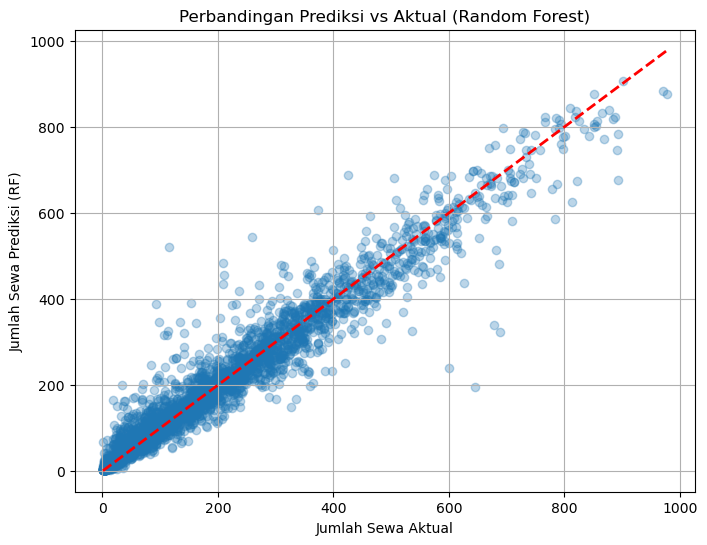

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Garis merah ideal
plt.xlabel('Jumlah Sewa Aktual')
plt.ylabel('Jumlah Sewa Prediksi (RF)')
plt.title('Perbandingan Prediksi vs Aktual (Random Forest)')
plt.grid(True)
plt.show()

FITUR PALING PENTING (TOP 10):
hr              0.609916
temp            0.120717
yr              0.080793
workingday      0.061329
hum             0.026235
atemp           0.025410
season_4        0.015232
weathersit_3    0.015139
windspeed       0.010118
weekday_5       0.005232
dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_20596\92793843.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.head(10).values, y=feature_importances.head(10).index, palette='viridis')


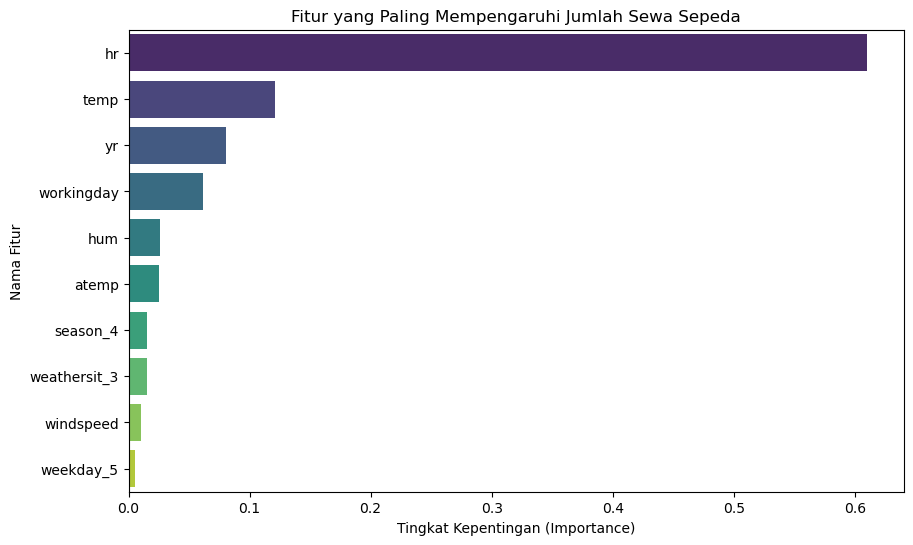

In [23]:
import seaborn as sns

feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("FITUR PALING PENTING (TOP 10):")
print(feature_importances.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.head(10).values, y=feature_importances.head(10).index, palette='viridis')
plt.title('Fitur yang Paling Mempengaruhi Jumlah Sewa Sepeda')
plt.xlabel('Tingkat Kepentingan (Importance)')
plt.ylabel('Nama Fitur')
plt.show()

## Kesimpulan & Rekomendasi Bisnis

Setelah melakukan evaluasi, model **Random Forest** terbukti jauh lebih unggul dibandingkan Linear Regression:
- **Linear Regression:** MAE = 103.14, R² = 0.40 (Kurang mampu menangkap pola naik-turun).
- **Random Forest:** MAE = 25.48, R² = 0.94 (Sangat akurat).

**Insight:**
Berdasarkan *Feature Importance*, faktor **Jam (hr)** dan **Suhu (temp)** adalah pendorong utama penyewaan. 

**Rekomendasi untuk Manajemen:**
1. Tambahkan stok sepeda ekstra pada **jam 08.00 dan 17.00** di hari kerja.
2. Kurangi stok atau alihkan ke perawatan pada **saat hujan** atau **suhu sangat dingin**.
3. Pada *notebook* ini, saya menggunakan target `cnt`. Untuk penelitian selanjutnya, saya akan memisahkan target menjadi `casual` dan `registered` untuk melihat pola perilaku pengguna yang berbeda.

In [24]:
print("Compare both model")
print("Rf:")
print(f"R-Squared (R2): {r2_rf:.4f}")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")

print("Linear regression:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-Squared (R2): {r2:.4f}")

Compare both model
Rf:
R-Squared (R2): 0.9420
Mean Absolute Error (MAE): 25.48
Linear regression:
Mean Absolute Error (MAE): 103.14
R-Squared (R2): 0.4086
